In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, ParameterGrid, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.calibration import calibration_curve
import lightgbm as lgb
import xgboost as xgb
import statsmodels.api as sm

In [2]:
df_train_val = pd.read_parquet('../data/data_binary_train_val.parquet')
df_train = pd.read_parquet('../data/data_binary_train.parquet')
df_val = pd.read_parquet('../data/data_binary_val.parquet')
df_test = pd.read_parquet('../data/data_binary_test.parquet')

fig_dir = "../figures"

In [3]:
y_col = 'default'
X_train_val = df_train_val.drop(columns=[y_col]).astype(float)
y_train_val = df_train_val[y_col]
X_train = df_train.drop(columns=[y_col]).astype(float)
y_train = df_train[y_col]
X_val = df_val.drop(columns=[y_col]).astype(float)
y_val = df_val[y_col]
X_test = df_test.drop(columns=[y_col]).astype(float)
y_test = df_test[y_col]

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Train: 97986, Val: 12898, Test: 11380


In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, weight=None, model_name="Model", plot=True, save_fig=True):
    """
    Train + evaluate model with:
    - Train/Test Accuracy
    - Train/Test AUC
    - ROC curve (test)
    - Calibration curve (test)
    """
    if weight is None:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=weight)

    # train
    y_prob_tr = model.predict_proba(X_train)[:, 1]
    y_pred_tr = (y_prob_tr >= 0.5).astype(int)
    acc_tr = accuracy_score(y_train, y_pred_tr)
    auc_tr = roc_auc_score(y_train, y_prob_tr)
    # test
    y_prob_te = model.predict_proba(X_test)[:, 1]
    y_pred_te = (y_prob_te >= 0.5).astype(int)
    acc_te = accuracy_score(y_test, y_pred_te)
    auc_te = roc_auc_score(y_test, y_prob_te)
    fpr, tpr, _ = roc_curve(y_test, y_prob_te)
    
    print(f"{model_name}:")
    print(f"  Train Acc: {acc_tr:.4f}, AUC: {auc_tr:.4f}")
    print(f"  Test  Acc: {acc_te:.4f}, AUC: {auc_te:.4f}")
    
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
        
        # --- ROC ---
        axes[0].plot(fpr, tpr, label=f"AUC = {auc_te:.3f}")
        axes[0].plot([0, 1], [0, 1], linestyle='--')
        axes[0].set_title(f"{model_name} ROC Curve")
        axes[0].set_xlabel("FPR")
        axes[0].set_ylabel("TPR")
        axes[0].legend()
        
        # --- Calibration ---
        prob_true, prob_pred = calibration_curve(y_test, y_prob_te, n_bins=10)
        axes[1].plot(prob_pred, prob_true, marker='o')
        axes[1].plot([0, 1], [0, 1], linestyle='--')
        axes[1].set_title(f"{model_name} Calibration Curve")
        axes[1].set_xlabel("Predicted Probability")
        axes[1].set_ylabel("Observed Frequency")
        
        plt.tight_layout()
        plt.show()

    if save_fig:
        # --- ROC ---
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc_te:.3f}")
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.title(f"{model_name} ROC Curve")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend()
        plt.savefig(f"{fig_dir}/{model_name}_roc.png", dpi=300, bbox_inches='tight')
        plt.close()

        # --- Calibration ---
        plt.figure()
        plt.plot(prob_pred, prob_true, marker='o')
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.title(f"{model_name} Calibration Curve")
        plt.xlabel("Predicted Probability")
        plt.ylabel("Observed Frequency")
        plt.savefig(f"../figures/{model_name}_calibration.png", dpi=300, bbox_inches='tight')
        plt.close()

    # return {"model": model, "y_prob": y_prob_te, "accuracy": acc_te, "auc": auc_te}

## Baseline Models

No feature or parameter selection.

Logistic Regression (Baseline):
  Train Acc: 0.8844, AUC: 0.7771
  Test  Acc: 0.8413, AUC: 0.5057


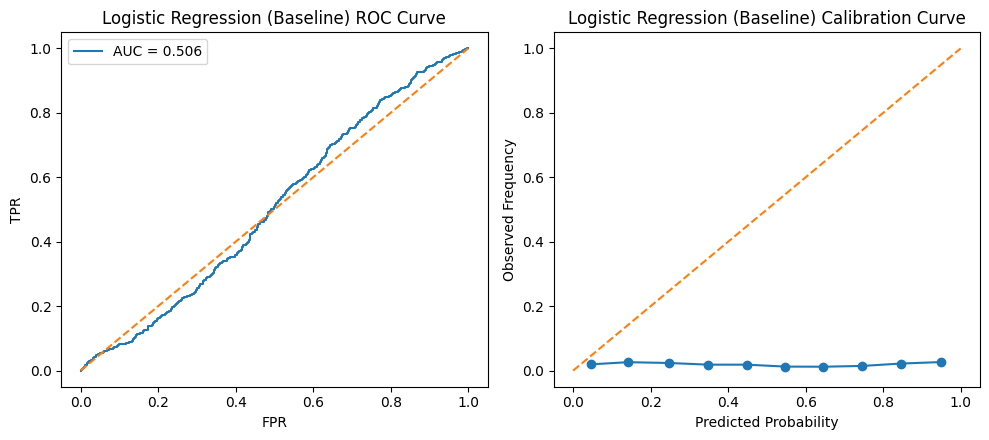

In [5]:
# Logistic Regression
lr_b = LogisticRegression(max_iter=1000, random_state=42)
evaluate_model(lr_b, X_train_val, y_train_val, X_test, y_test, model_name="Logistic Regression (Baseline)")

LightGBM (Baseline):
  Train Acc: 0.8875, AUC: 0.8390
  Test  Acc: 0.9786, AUC: 0.5410


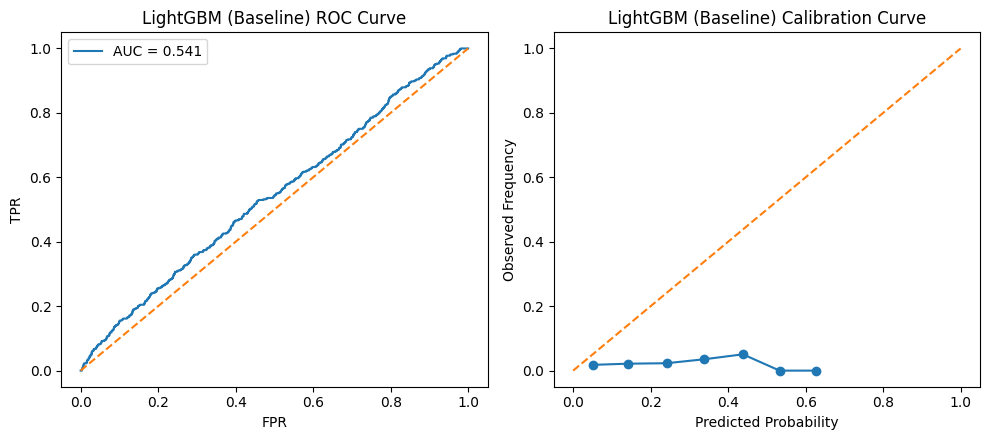

In [6]:
# LightGBM
lgbm_b = lgb.LGBMClassifier(random_state=42, verbosity=-1)
evaluate_model(lgbm_b, X_train_val, y_train_val, X_test, y_test, model_name="LightGBM (Baseline)")

XGBoost (Baseline):
  Train Acc: 0.8991, AUC: 0.8927
  Test  Acc: 0.9678, AUC: 0.5390


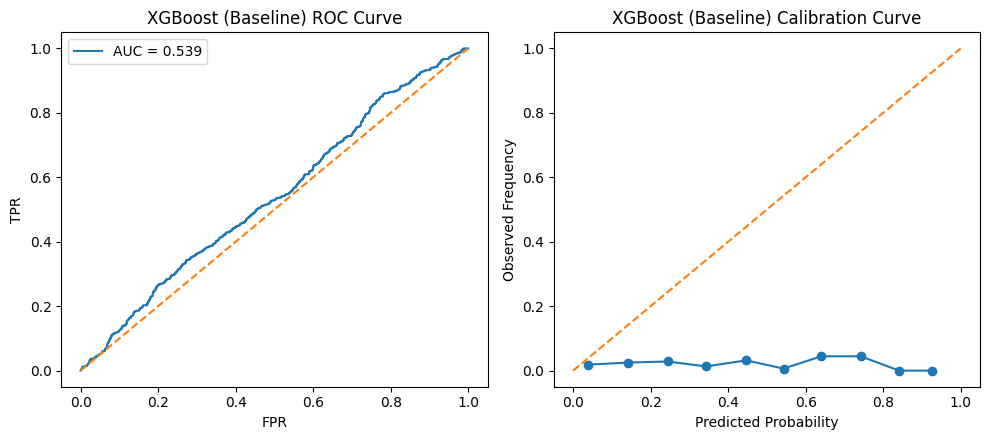

In [7]:
# XGBoost
xgbm_b = xgb.XGBClassifier(random_state=42, verbosity=0)
evaluate_model(xgbm_b, X_train_val, y_train_val, X_test, y_test, model_name="XGBoost (Baseline)")

Random Forest (Baseline):
  Train Acc: 1.0000, AUC: 1.0000
  Test  Acc: 0.9799, AUC: 0.5223


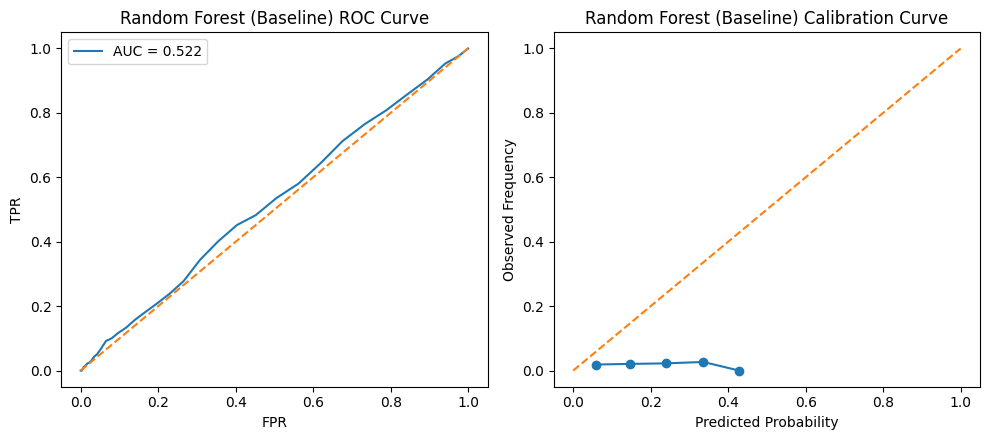

In [8]:
# Random Forest
rf_b = RandomForestClassifier(random_state=42)
evaluate_model(rf_b, X_train_val, y_train_val, X_test, y_test, model_name="Random Forest (Baseline)")

## Feature Selection + Parameter Search

In [9]:
tscv = TimeSeriesSplit(n_splits=5)

In [10]:
def ts_cv_auc(model, X, y):
    aucs = []
    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_pred))
    
    return np.mean(aucs)

def get_stable_importance(X, y):
    imps = []
    for tr_idx, val_idx in tscv.split(X):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        m = lgb.LGBMClassifier(random_state=42, verbosity=-1)
        m.fit(X_tr, y_tr)
        imps.append(m.feature_importances_)
    imp = pd.Series(np.mean(imps, axis=0), index=X.columns).sort_values(ascending=False)
    
    return imp

def run_ts_grid(model_class, param_grid, X, y, fixed_params=None):
    results = []
    
    for i, p in enumerate(ParameterGrid(param_grid)):
        params = {**(fixed_params or {}), **p}
        print(f"[{i+1}] Testing params: {params}")
        model = model_class(**params)
        
        auc = ts_cv_auc(model, X, y)
        results.append({**p, 'auc': auc})
    
    df = pd.DataFrame(results)
    best_params = df.loc[df['auc'].idxmax()].drop('auc').to_dict()
    
    for k, v in best_params.items():
        if isinstance(v, float) and v.is_integer():
            best_params[k] = int(v)
    
    return df, best_params

### Feature Selection

Top 15 important features:
disbursement_lag_days     256.4
log_grossapproval         247.8
l2locid_count             211.8
jobssupported             139.0
EHE_growth_m_st           118.2
crime_rate_growth_m_st    109.4
crime_rate_m_st           100.2
unemp_m_st                 99.0
CPI_m                      96.2
GDP_y_st                   94.4
GDP_growth_y_st            88.4
EHE_m_st                   85.6
PPI_growth_m               79.8
vix_m                      70.6
HPI_growth_m               69.4
dtype: float64


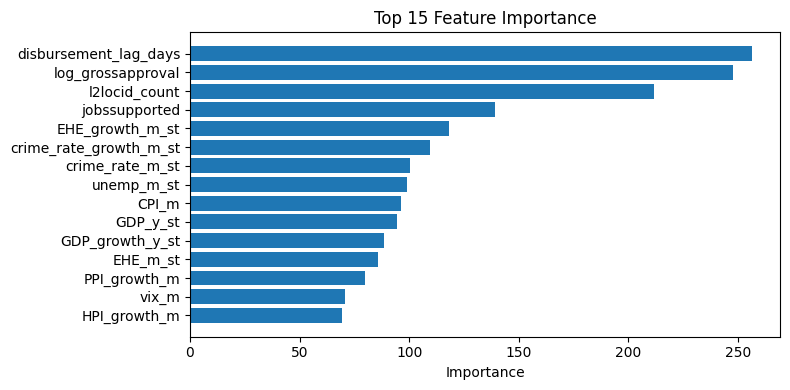

In [11]:
imp = get_stable_importance(X_train_val, y_train_val)

top_n = 15
imp_top = imp.head(top_n)
print(f"Top {top_n} important features:")
print(imp_top)

plt.figure(figsize=(8, 4))
plt.barh(imp_top.index[::-1], imp_top.values[::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importance")
plt.tight_layout()
plt.savefig(f"{fig_dir}/feature_selection.png", dpi=300, bbox_inches='tight')
plt.show()

k (90% importance) = 39


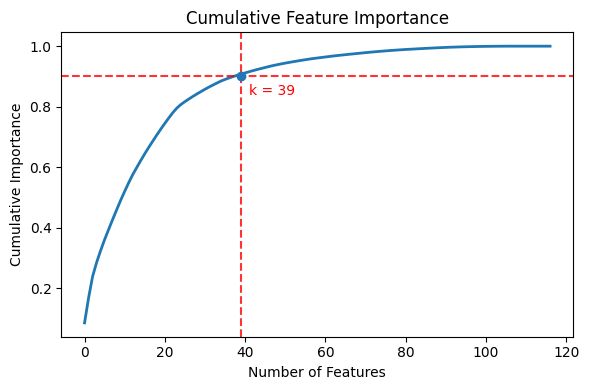

In [12]:
cum_imp = imp.cumsum() / imp.sum()

k_90 = (cum_imp >= 0.9).idxmax()
k_90 = imp.index.get_loc(k_90) + 1
print(f"k (90% importance) = {k_90}")

plt.figure(figsize=(6, 4))
plt.plot(cum_imp.values, linewidth=2)
plt.axvline(k_90, linestyle='--', color='r', alpha=0.8)
plt.axhline(0.9, linestyle='--', color='r', alpha=0.8)
plt.scatter([k_90], [0.9], zorder=3)
plt.text(k_90 + 2, 0.84, f'k = {k_90}', color='r', fontsize=10)
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance")
plt.tight_layout()
plt.savefig(f"{fig_dir}/cumulative_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

### Parameter Grid Search

In [13]:
sel_cols = imp[:k_90].index.to_list()
X_tv_sel = X_train_val[sel_cols]
X_test_sel = X_test[sel_cols]
y_tv = y_train_val

In [14]:
# Logistic Regression
lr_grid = {
    'penalty': ['elasticnet'],
    'C': np.logspace(-2, 2, 5),
    'l1_ratio': [0, 0.5, 1],
}
lr_fixed = {
    'solver': 'saga',
    'max_iter': 5000,
    'random_state': 42
}
lr_df, best_lr_params = run_ts_grid(LogisticRegression, lr_grid, X_tv_sel, y_tv, lr_fixed)

[1] Testing params: {'solver': 'saga', 'max_iter': 5000, 'random_state': 42, 'C': np.float64(0.01), 'l1_ratio': 0, 'penalty': 'elasticnet'}
[2] Testing params: {'solver': 'saga', 'max_iter': 5000, 'random_state': 42, 'C': np.float64(0.01), 'l1_ratio': 0.5, 'penalty': 'elasticnet'}
[3] Testing params: {'solver': 'saga', 'max_iter': 5000, 'random_state': 42, 'C': np.float64(0.01), 'l1_ratio': 1, 'penalty': 'elasticnet'}
[4] Testing params: {'solver': 'saga', 'max_iter': 5000, 'random_state': 42, 'C': np.float64(0.1), 'l1_ratio': 0, 'penalty': 'elasticnet'}
[5] Testing params: {'solver': 'saga', 'max_iter': 5000, 'random_state': 42, 'C': np.float64(0.1), 'l1_ratio': 0.5, 'penalty': 'elasticnet'}
[6] Testing params: {'solver': 'saga', 'max_iter': 5000, 'random_state': 42, 'C': np.float64(0.1), 'l1_ratio': 1, 'penalty': 'elasticnet'}
[7] Testing params: {'solver': 'saga', 'max_iter': 5000, 'random_state': 42, 'C': np.float64(1.0), 'l1_ratio': 0, 'penalty': 'elasticnet'}
[8] Testing params: 

In [28]:
# LightGBM
lgb_grid = {
    'num_leaves': [31, 63, 127],
    'max_depth': [5, 10, -1],
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.05],
}
lgb_fixed = {
    'random_state': 42,
    'verbosity': -1
}
lgb_df, best_lgb_params = run_ts_grid(lgb.LGBMClassifier, lgb_grid, X_tv_sel, y_tv, lgb_fixed)

[1] Testing params: {'random_state': 42, 'verbosity': -1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 31}
[2] Testing params: {'random_state': 42, 'verbosity': -1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 63}
[3] Testing params: {'random_state': 42, 'verbosity': -1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 127}
[4] Testing params: {'random_state': 42, 'verbosity': -1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
[5] Testing params: {'random_state': 42, 'verbosity': -1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 63}
[6] Testing params: {'random_state': 42, 'verbosity': -1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 127}
[7] Testing params: {'random_state': 42, 'verbosity': -1, 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 50, 'num_leaves': 31}
[8] Testing params: {'random_state': 42, 'verbosi

In [27]:
# XGBoost
xgb_grid = {
    'max_depth': [2, 3, 4, 5],
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1, 0.2],
}
xgb_fixed = {
    'random_state': 42,
    'verbosity': 0,
    'use_label_encoder': False
}
xgb_df, best_xgb_params = run_ts_grid(xgb.XGBClassifier, xgb_grid, X_tv_sel, y_tv, xgb_fixed)

[1] Testing params: {'random_state': 42, 'verbosity': 0, 'use_label_encoder': False, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
[2] Testing params: {'random_state': 42, 'verbosity': 0, 'use_label_encoder': False, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
[3] Testing params: {'random_state': 42, 'verbosity': 0, 'use_label_encoder': False, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
[4] Testing params: {'random_state': 42, 'verbosity': 0, 'use_label_encoder': False, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
[5] Testing params: {'random_state': 42, 'verbosity': 0, 'use_label_encoder': False, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50}
[6] Testing params: {'random_state': 42, 'verbosity': 0, 'use_label_encoder': False, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
[7] Testing params: {'random_state': 42, 'verbosity': 0, 'use_label_encoder': False, 'learning_rate': 0.05, 'max_depth': 5, 'n_estima

In [17]:
# Random Forest
rf_grid = {
    'max_depth': [5, 10, 20],
    'n_estimators': [100, 300],
    'min_samples_split': [2, 5],
}
rf_fixed = {
    'random_state': 42,
    'n_jobs': -1
}
rf_df, best_rf_params = run_ts_grid(RandomForestClassifier, rf_grid, X_tv_sel, y_tv, rf_fixed)

[1] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
[2] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
[3] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
[4] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
[5] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
[6] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
[7] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
[8] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
[9] Testing params: {'random_state': 42, 'n_jobs': -1, 'max_depth': 

In [76]:
print('Best params:')
print('LR ', best_lr_params)
print('LGB', best_lgb_params)
print('XGB', best_xgb_params)
print('RF ', best_rf_params)

Best params:
LR  {'C': 10, 'l1_ratio': 1, 'penalty': 'elasticnet'}
LGB {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 63}
XGB {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
RF  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}


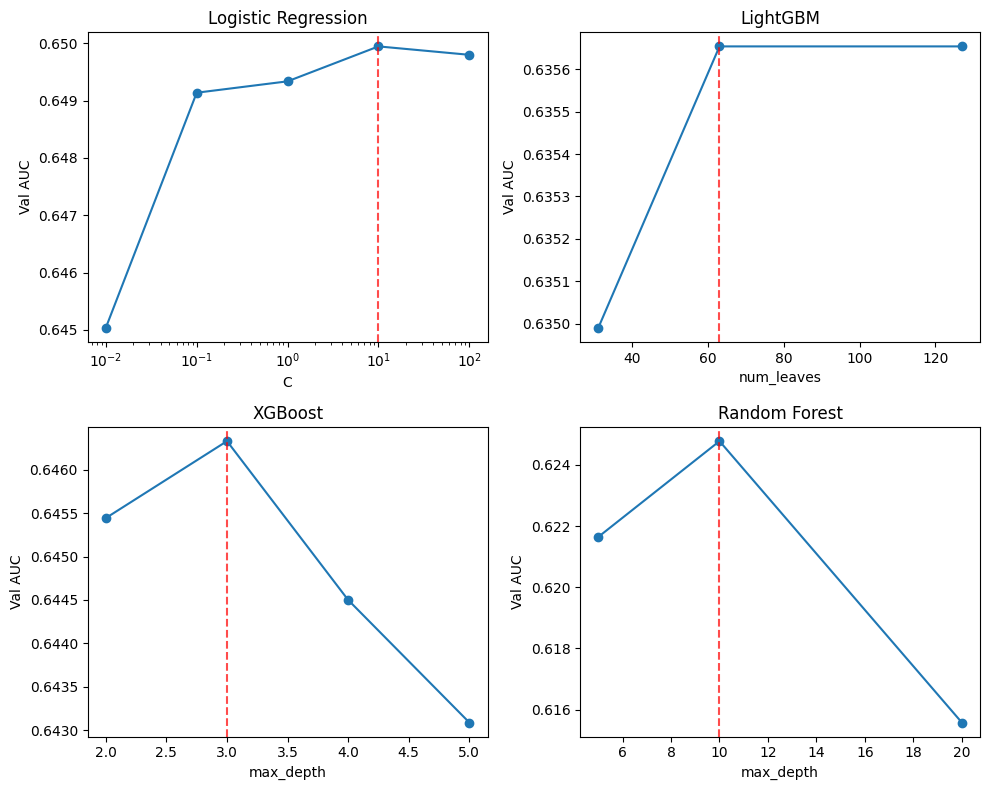

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# LR: C
lr_plot_key = 'C'
lr_agg = lr_df.groupby(lr_plot_key)['auc'].max().sort_index()
axes[0,0].plot(lr_agg.index.astype(float), lr_agg.values, 'o-')
axes[0,0].set_xscale('log')
axes[0,0].set_xlabel(lr_plot_key)
axes[0,0].set_ylabel('Val AUC')
axes[0,0].set_title('Logistic Regression')
axes[0,0].axvline(best_lr_params[lr_plot_key], color='r', linestyle='--', alpha=0.7)

# LGB: num_leaves
lgb_plot_key = 'num_leaves'
lgb_agg = lgb_df.groupby(lgb_plot_key)['auc'].max().sort_index()
axes[0,1].plot(lgb_agg.index, lgb_agg.values, 'o-')
axes[0,1].set_xlabel(lgb_plot_key)
axes[0,1].set_ylabel('Val AUC')
axes[0,1].set_title('LightGBM')
axes[0,1].axvline(best_lgb_params[lgb_plot_key], color='r', linestyle='--', alpha=0.7)

# XGB: max_depth
xgb_plot_key = 'max_depth'
xgb_agg = xgb_df.groupby(xgb_plot_key)['auc'].max().sort_index()
axes[1,0].plot(xgb_agg.index, xgb_agg.values, 'o-')
axes[1,0].set_xlabel(xgb_plot_key)
axes[1,0].set_ylabel('Val AUC')
axes[1,0].set_title('XGBoost')
axes[1,0].axvline(best_xgb_params[xgb_plot_key], color='r', linestyle='--', alpha=0.7)

# RF: max_depth
rf_plot_key = 'max_depth'
rf_agg = rf_df.groupby(rf_plot_key)['auc'].max().sort_index()
axes[1,1].plot(rf_agg.index, rf_agg.values, 'o-')
axes[1,1].set_xlabel(rf_plot_key)
axes[1,1].set_ylabel('Val AUC')
axes[1,1].set_title('Random Forest')
axes[1,1].axvline(best_rf_params[rf_plot_key], color='r', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Improved Models

LightGBM (Improved):
  Train Acc: 0.8954, AUC: 0.7969
  Test  Acc: 0.9799, AUC: 0.6107


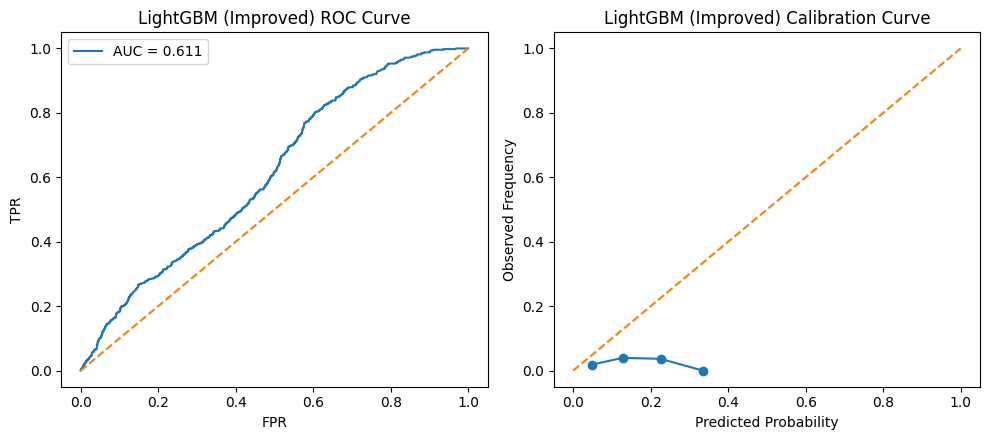

In [15]:
# LightGBM (best params from grid)
lgbm_sel = lgb.LGBMClassifier(**{**(lgb_fixed), **best_lgb_params})
evaluate_model(lgbm_sel, X_tv_sel, y_tv, X_test_sel, y_test, model_name="LightGBM (Improved)")

XGBoost (Improved):
  Train Acc: 0.8956, AUC: 0.7992
  Test  Acc: 0.9799, AUC: 0.6274


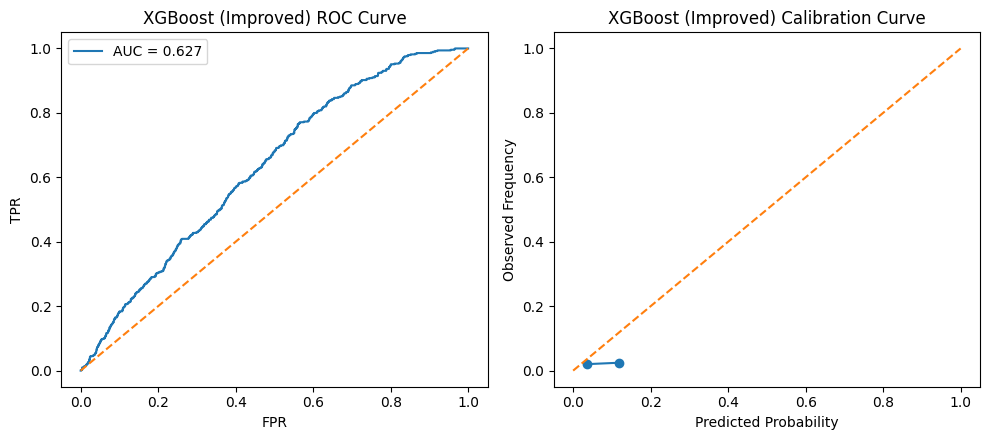

In [16]:
# XGBoost (best params from grid)
xgb_sel = xgb.XGBClassifier(**{**(xgb_fixed), **best_xgb_params})
evaluate_model(xgb_sel, X_tv_sel, y_tv, X_test_sel, y_test, model_name="XGBoost (Improved)")

Logistic Regression (Improved):
  Train Acc: 0.8948, AUC: 0.7744
  Test  Acc: 0.9202, AUC: 0.5214


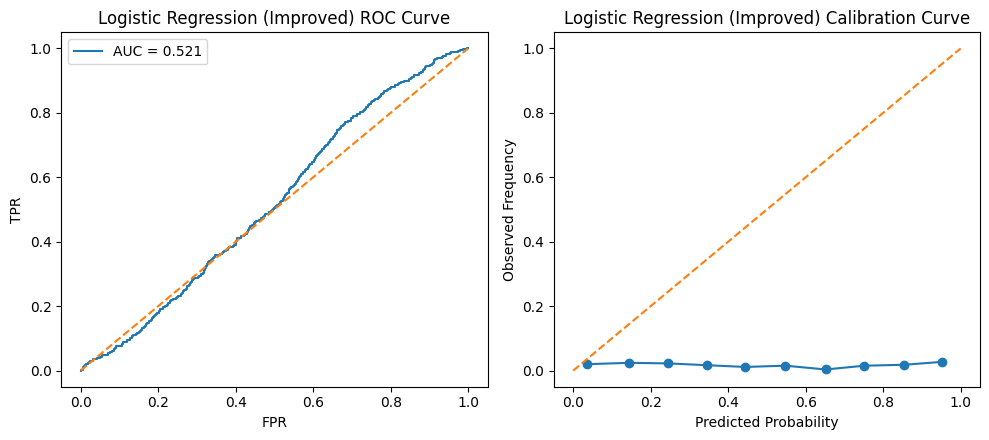

In [17]:
# Logistic Regression (best params from grid)
lr_sel = LogisticRegression(**{**(lr_fixed), **best_lr_params})
evaluate_model(lr_sel, X_tv_sel, y_tv, X_test_sel, y_test, model_name="Logistic Regression (Improved)")

Random Forest (Improved):
  Train Acc: 0.8975, AUC: 0.8435
  Test  Acc: 0.9799, AUC: 0.6527


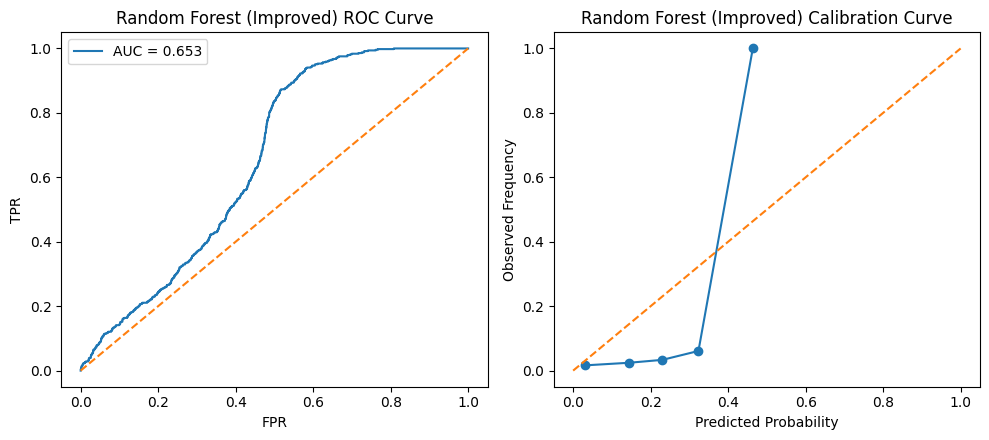

In [18]:
# Random Forest (best params from grid)
rf_sel = RandomForestClassifier(**{**(rf_fixed), **best_rf_params})
evaluate_model(rf_sel, X_tv_sel, y_tv, X_test_sel, y_test, model_name="Random Forest (Improved)")

## Distribution Shift Adjustment

### Covariate Shift

In [20]:
# use only cols uncorrelated with time (because we split the dataset by time)
domain_cols = ['disbursement_lag_days', 'log_grossapproval', 'jobssupported', 'log_thirdpartydollars', 'terminmonths'] + \
	[col for col in df_train.columns if col.startswith('borrstate_') or col.startswith('naicscode_')]

In [21]:
# label train as 0, test as 1
X_combined = pd.concat([X_train[domain_cols], X_test[domain_cols]])
y_domain = np.array([0]*len(X_train) + [1]*len(X_test))

# train a simple classifier to distinguish train/test
domain_clf = lgb.LGBMClassifier(random_state=42, verbosity=-1)
domain_clf.fit(X_combined, y_domain)

auc_domain = roc_auc_score(y_domain, domain_clf.predict_proba(X_combined)[:,1])
print(f"Domain AUC: {auc_domain:.4f}")

Domain AUC: 0.9512


Top 10 important features:
                  feature  importance
1       log_grossapproval         592
0   disbursement_lag_days         521
2           jobssupported         426
3   log_thirdpartydollars         365
4            terminmonths         132
77      naicscode_Unknown          88
68           naicscode_53          46
8            borrstate_CA          35
72           naicscode_62          33
74           naicscode_72          32


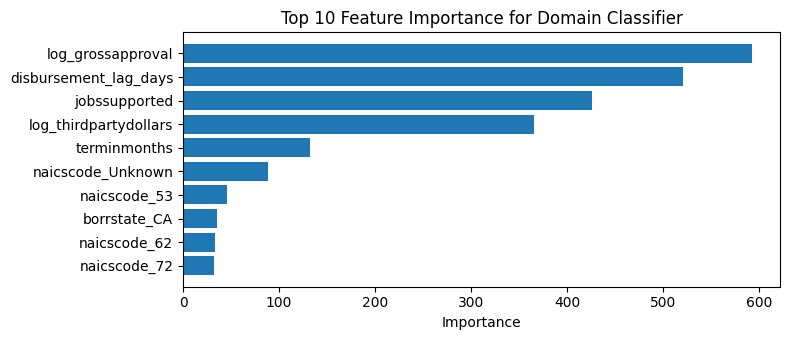

In [22]:
# LightGBM feature importance
importances = domain_clf.feature_importances_
feature_names = X_train[domain_cols].columns

# sort by importance
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

top_n = 10
print(f"Top {top_n} important features:")
print(importance_df.head(top_n))

# visualize top 30 important features
plt.figure(figsize=(8, 3.5))
plt.barh(importance_df['feature'][:top_n][::-1], importance_df['importance'][:top_n][::-1])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importance for Domain Classifier')
plt.tight_layout()
plt.savefig(f"{fig_dir}/domain_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
p_test = domain_clf.predict_proba(X_train_val[domain_cols])[:, 1]
p_train = 1 - p_test
cov_weights = p_test / p_train  # importance weight
cov_weights = pd.Series(cov_weights).clip(lower=0.01, upper=10).values # clip to [0.01, 10]

### Label Shift

In [24]:
# train/test default rate
pi_train_val = y_train_val.mean()
pi_test = y_test.mean()

# label shift weights
w1 = pi_test / pi_train_val
w0 = (1 - pi_test) / (1 - pi_train_val)

# label weights for train data
label_weights = np.where(y_train_val == 1, w1, w0)

### Final Models

In [25]:
final_weights = cov_weights * label_weights

LightGBM (Final):
  Train Acc: 0.8954, AUC: 0.7762
  Test  Acc: 0.9799, AUC: 0.7114


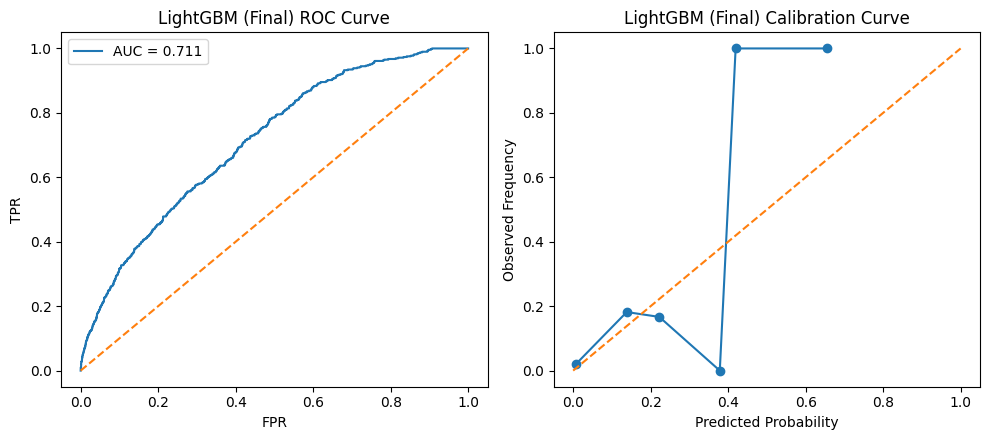

In [26]:
# LightGBM (best params from grid, weight adjusted)
lgbm_final = lgb.LGBMClassifier(**{**(lgb_fixed), **best_lgb_params})
evaluate_model(lgbm_final, X_tv_sel, y_tv, X_test_sel, y_test, weight=final_weights, model_name="LightGBM (Final)")

XGBoost (Final):
  Train Acc: 0.8951, AUC: 0.7656
  Test  Acc: 0.9799, AUC: 0.7050


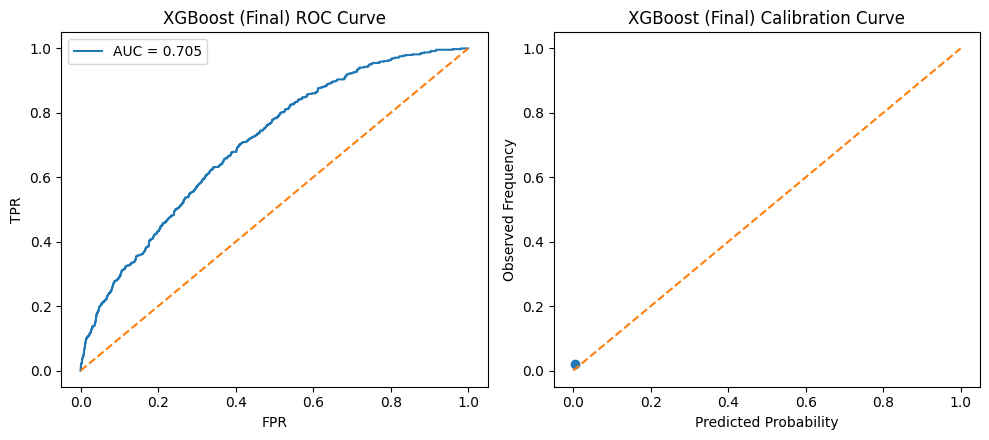

In [27]:
# XGBoost (best params from grid, weight adjusted)
xgb_final = xgb.XGBClassifier(**{**(xgb_fixed), **best_xgb_params})
evaluate_model(xgb_final, X_tv_sel, y_tv, X_test_sel, y_test, weight=final_weights, model_name="XGBoost (Final)")

Logistic Regression (Final):
  Train Acc: 0.8951, AUC: 0.7492
  Test  Acc: 0.9796, AUC: 0.5795


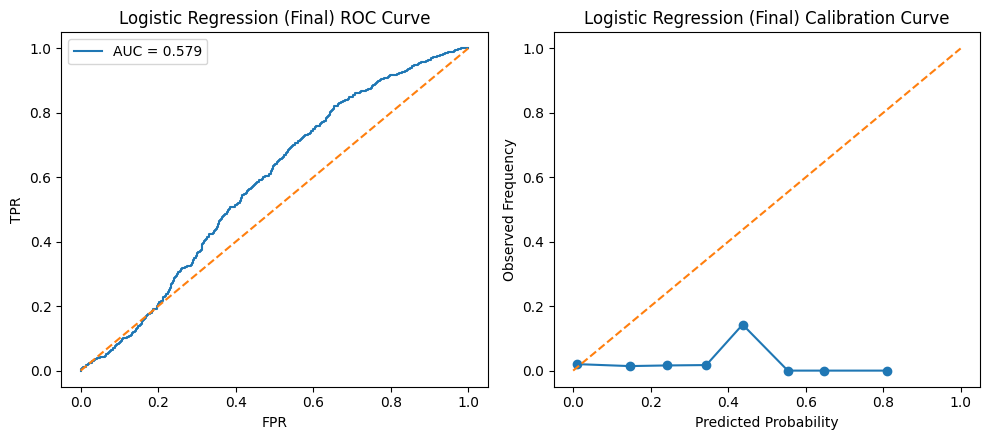

In [28]:
# Logistic Regression (best params from grid, weight adjusted)
lr_final = LogisticRegression(**{**(lr_fixed), **best_lr_params})
evaluate_model(lr_final, X_tv_sel, y_tv, X_test_sel, y_test, weight=final_weights, model_name="Logistic Regression (Final)")

Random Forest (Final):
  Train Acc: 0.8951, AUC: 0.8513
  Test  Acc: 0.9799, AUC: 0.7203


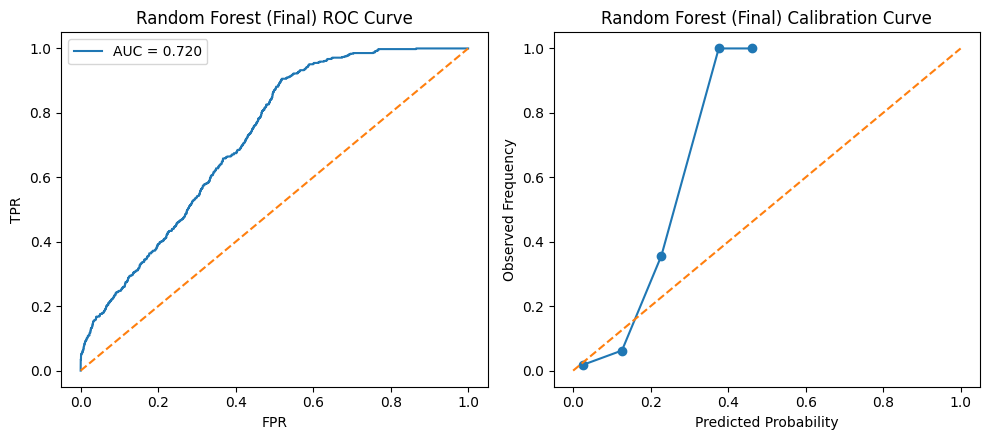

In [29]:
# Random Forest (best params from grid, weight adjusted)
rf_final = RandomForestClassifier(**{**(rf_fixed), **best_rf_params})
evaluate_model(rf_final, X_tv_sel, y_tv, X_test_sel, y_test, weight=final_weights, model_name="Random Forest (Final)")

In [ ]:
# use the same parameters and sample weights for statsmodels LogisticRegression
X_sm = sm.add_constant(X_tv_sel)  # add a constant
model_sm = sm.GLM(
    y_tv,
    X_sm,
    family=sm.families.Binomial(),
    freq_weights=final_weights   # sample weights
)
result_sm = model_sm.fit(maxiter=1000, random_state=42)

summary_df = pd.DataFrame({
    "coef": result_sm.params,
    "std_err": result_sm.bse,
    "z": result_sm.tvalues,
    "p_value": result_sm.pvalues
})
sig_df = summary_df[summary_df["p_value"] < 0.05]
sig_df

,coef,std_err,z,p_value
const,-2.259543,0.105383,-21.441273,5.508603e-102
disbursement_lag_days,0.102974,0.027107,3.798782,1.454090e-04
jobssupported,0.137334,0.031488,4.361532,1.291550e-05
CPI_m,-1.503399,0.373036,-4.030171,5.573637e-05
GDP_y_st,-0.896035,0.282753,-3.168964,1.529834e-03
EHE_m_st,0.855912,0.307069,2.787364,5.313877e-03
vix_m,0.130901,0.043579,3.003792,2.666378e-03
HPI_growth_m,-0.107946,0.032230,-3.349292,8.101828e-04
tnx_m,-0.172759,0.074972,-2.304328,2.120421e-02
PPI_m,0.439073,0.221496,1.982303,4.744538e-02
